<a href="https://colab.research.google.com/github/sof1a03/Process-Mining/blob/main/question2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Filtering rule:**  
We only consider assets with at least 10 total cases (to avoid tiny‐N noise),  
and we require the Wilson 95% CI for the reopen rate to be no wider than 0.3.  
In code, that means:
```python
stable_assets = asset_stats[(asset_stats['total'] >= 10) & (asset_stats['ci_width'] <= 0.3)]


In [34]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statistics
from statsmodels.stats.proportion import proportion_confint
#from pm4py.objects.conversion.log import converter as log_converter

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

Load the CSV with proper parsing

In [7]:
# 1) Load with correct separators & decimals
path = os.path.join(os.getcwd(), "/content/incidentProcess_custom.csv")
data = pd.read_csv(path,
                   sep=";",
                   decimal=",",
                   thousands=".")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Incident ID              303819 non-null  object 
 1   Activity                 303819 non-null  object 
 2   ActivityTimeStamp        303819 non-null  object 
 3   Asset Affected           303819 non-null  object 
 4   Asset Type Affected      303819 non-null  object 
 5   Asset SubType Affected   303819 non-null  object 
 6   Service Affected         303819 non-null  object 
 7   Status                   303819 non-null  object 
 8   Impact                   303819 non-null  int64  
 9   Urgency                  303819 non-null  int64  
 10  Priority                 303819 non-null  int64  
 11  Category                 303819 non-null  object 
 12  Number of Reassignments  303810 non-null  float64
 13  Open Time                303819 non-null  object 
 14  Reop

Label each case as reopened (if any activity has 'Reopen Time'), creating a binary flag

In [8]:
reopened_cases = data[data['Reopen Time'].notna()]['Incident ID'].unique()
data['Reopened'] = data['Incident ID'].isin(reopened_cases).astype(int)

Parse timestamps

In [9]:
data["ActivityTimeStamp"] = pd.to_datetime(
    data["ActivityTimeStamp"],
    infer_datetime_format=True,
    utc=True
)
data["Open Time"]  = pd.to_datetime(data["Open Time"],  dayfirst=True)
data["Close Time"] = pd.to_datetime(data["Close Time"], dayfirst=True)

<ipython-input-9-faf82bcd3eb6>:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data["ActivityTimeStamp"] = pd.to_datetime(


Compute handle time in hours (overwrite unreliable column)

In [10]:
data['computed_handle_hours'] = (data['Close Time'] - data['Open Time']).dt.total_seconds() / 3600
data.drop(columns=['Handle Time (Hours)'], inplace=True)

In [11]:
# data.to_csv("disco_asset_reopen_analysis.csv", index=False)

Reduce to case-level: keep first asset + reopen flag

In [12]:
# Case-level aggregation (keep only relevant columns for each case)
case_df = data.groupby('Incident ID').agg({
    'Reopened': 'max',
    'Asset Caused': 'first',
    'Asset Type Caused': 'first',
    'Asset SubType Caused': 'first',
    'Closure Code': 'first'
}).reset_index()


In [13]:
case_df

,Incident ID,Reopened,Asset Caused,Asset Type Caused,Asset SubType Caused,Closure Code
0,IM0000004,0,SUB000508,subapplication,Web Based Application,Other
1,IM0000005,1,WBA000124,application,Web Based Application,Software
2,IM0000006,0,DTA000024,application,Desktop Application,No error - works as designed
3,IM0000011,0,WBA000124,application,Web Based Application,Operator error
4,IM0000012,0,SUB000508,subapplication,Web Based Application,Other
...,...,...,...,...,...,...
46596,IM0047053,0,SBA000464,application,Server Based Application,Other
46597,IM0047054,0,SBA000461,application,Server Based Application,User error
46598,IM0047055,0,LAP000019,computer,Laptop,Hardware
46599,IM0047056,0,WBA000058,application,Web Based Application,Software


Sanity check: % of reopened incidents

In [14]:
df_reopened = case_df[case_df['Reopened'] == 1]

In [15]:
reopen_pct = case_df['Reopened'].mean() * 100
print(f"Percentage of reopened cases: {reopen_pct:.2f}%")

Percentage of reopened cases: 4.90%


Filter for statistically meaningful assets (≥10 cases)

In [16]:
# Minimum threshold
min_cases = 10

# Count all occurrences
asset_counts = case_df['Asset Caused'].value_counts()
valid_assets = asset_counts[asset_counts >= min_cases].index

# Filter your case-level DataFrame
case_df = case_df[case_df['Asset Caused'].isin(valid_assets)]

Compute per-asset reopen counts, totals, and Wilson CIs

In [17]:
asset_stats = case_df.groupby('Asset Caused')['Reopened'].agg(['sum', 'count']).rename(columns={'sum': 'reopened', 'count': 'total'})
asset_stats['ci_lower'], asset_stats['ci_upper'] = proportion_confint(asset_stats['reopened'], asset_stats['total'], alpha=0.05, method='wilson')
asset_stats['ci_width'] = asset_stats['ci_upper'] - asset_stats['ci_lower']
asset_stats['reopen_rate'] = asset_stats['reopened'] / asset_stats['total']

Filter by confidence width ≤ 0.3 (recommended threshold)

In [18]:
stable_assets = asset_stats[asset_stats['ci_width'] <= 0.3].copy()
stable_assets = stable_assets.sort_values('reopen_rate', ascending=False)

# Show top 10 risky assets (statistically reliable)
print("Top statistically reliable risky assets:")
print(stable_assets.head(10).round(3))

Top statistically reliable risky assets:
              reopened  total  ci_lower  ci_upper  ci_width  reopen_rate
Asset Caused                                                            
WSR000393           23     88     0.181     0.362     0.181        0.261
SAP000004          158    717     0.192     0.252     0.061        0.220
WSR000394           16     95     0.106     0.256     0.150        0.168
SBA000029           11     80     0.079     0.230     0.151        0.138
SAP000005           35    273     0.094     0.173     0.079        0.128
SBA000263          273   2154     0.113     0.141     0.028        0.127
SUB000465            9     74     0.065     0.215     0.150        0.122
SAP000003           11     92     0.068     0.202     0.133        0.120
SUB000521           16    139     0.072     0.179     0.107        0.115
ADB000010           16    141     0.071     0.176     0.105        0.113


LIFT

In [19]:
# Compute LIFT: how much more likely an asset leads to reopen
overall_reopen_rate = case_df['Reopened'].mean()
stable_assets['lift'] = stable_assets['reopen_rate'] / overall_reopen_rate

# Sort by lift
stable_assets = stable_assets.sort_values('lift', ascending=False)

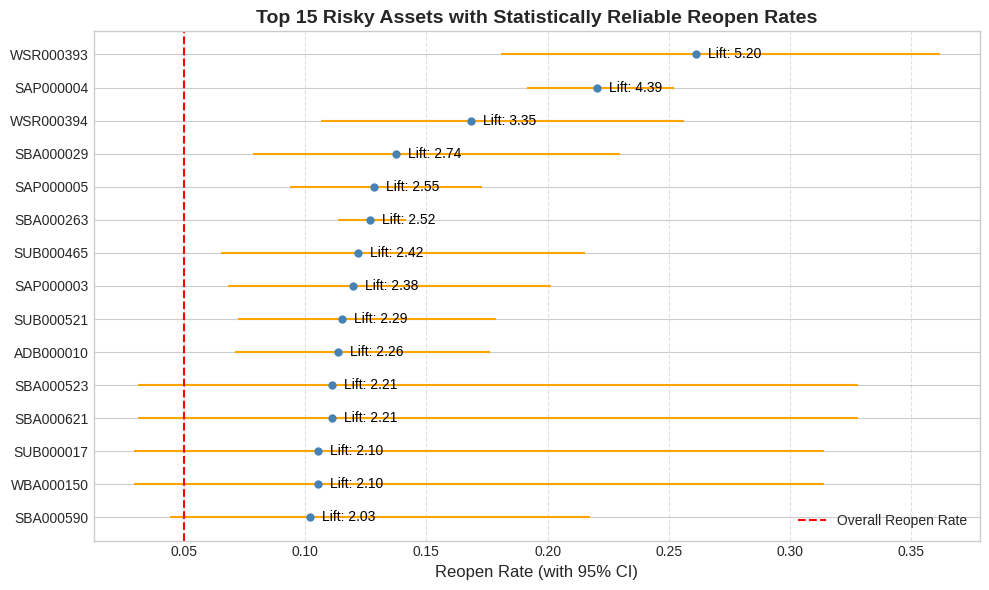

In [20]:
top_n = 15
plot_data = stable_assets.sort_values('reopen_rate', ascending=False).head(top_n)

# Setup
fig, ax = plt.subplots(figsize=(10, 6))

# Data
x = plot_data['reopen_rate']
y = plot_data.index
xerr_low = (x - plot_data['ci_lower']).clip(lower=0)
xerr_high = (plot_data['ci_upper'] - x).clip(lower=0)

# Plot error bars
ax.errorbar(
    x=x,
    y=y,
    xerr=[xerr_low, xerr_high],
    fmt='o',
    color='steelblue',
    ecolor='orange',
    elinewidth=1.5,
    capsize=4,
    markerfacecolor='steelblue',
    markeredgewidth=0
)

# Add lift annotations
for i, (xval, lift) in enumerate(zip(x, plot_data['lift'])):
    ax.text(xval + 0.005, i, f"Lift: {lift:.2f}", va='center', fontsize=10, color='black')

# Vertical baseline for context
ax.axvline(overall_reopen_rate, color='red', linestyle='--', label='Overall Reopen Rate')

# Labels
ax.set_xlabel("Reopen Rate (with 95% CI)", fontsize=12)
ax.set_title("Top 15 Risky Assets with Statistically Reliable Reopen Rates", fontsize=14, weight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
ax.legend()

# Style
plt.tight_layout()
plt.gca().invert_yaxis()  # optional: highest risk at top
plt.show()

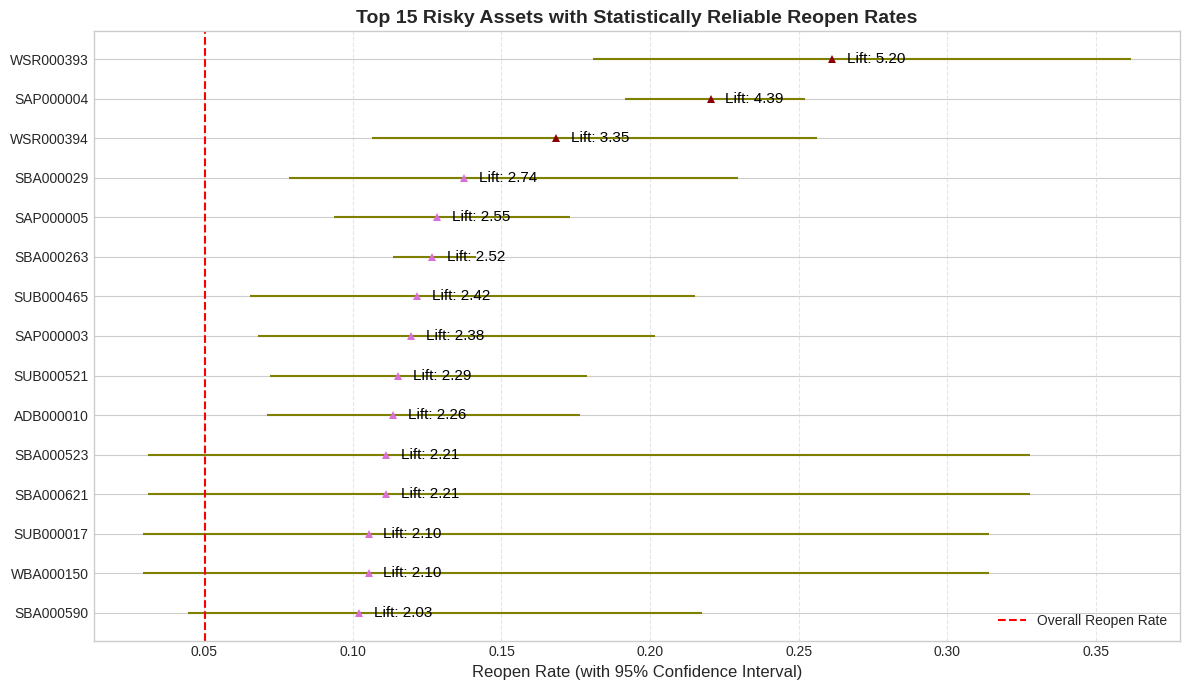

In [21]:
# Apply professional visual style
plt.style.use('seaborn-v0_8-whitegrid')

# Number of top risky assets to show
top_n = 15
plot_data = stable_assets.sort_values('reopen_rate', ascending=False).head(top_n).copy()

# Set up plot
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
x = plot_data['reopen_rate']
y = plot_data.index
xerr_low = (x - plot_data['ci_lower']).clip(lower=0)
xerr_high = (plot_data['ci_upper'] - x).clip(lower=0)
lift = plot_data['lift']
sample_size = plot_data['total']

# Define color: top 3 in red, rest in blue
colors = ['darkred' if i < 3 else 'orchid' for i in range(len(plot_data))]

# Plot error bars and points
for i, (xval, low, high, color) in enumerate(zip(x, xerr_low, xerr_high, colors)):
    ax.errorbar(
        x=xval,
        y=i,
        xerr=[[low], [high]],
        fmt='^',
        ecolor='olive',
        color=color,
        capsize=4,
        elinewidth=1.5,
        markerfacecolor=color,
        markeredgewidth=0
    )

# Add lift annotations
for i, (xval, l) in enumerate(zip(x, lift)):
    ax.text(xval + 0.005, i, f"Lift: {l:.2f}", va='center', fontsize=11, color='black')

# OPTIONAL: Add sample size annotations (uncomment if you want it)
# for i, (xval, n) in enumerate(zip(x, sample_size)):
#     ax.text(xval + 0.12, i, f"N={n}", va='center', fontsize=8, color='dimgray')

# Add vertical line for overall average
ax.axvline(overall_reopen_rate, color='red', linestyle='--', label='Overall Reopen Rate')

# Formatting
ax.set_yticks(range(len(y)))
ax.set_yticklabels(y)
ax.set_xlabel("Reopen Rate (with 95% Confidence Interval)", fontsize=12)
ax.set_title("Top 15 Risky Assets with Statistically Reliable Reopen Rates", fontsize=14, weight='bold')
ax.invert_yaxis()  # Optional: highest risk at top
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
#subtype analysis
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Lift', ascending=False)
print(subtype_comparison.head(10).round(2))

                      All %  Reopened %   Lift
Asset SubType Caused                          
Router                 0.00        0.09    inf
VDI                    0.00        0.09    inf
Banking Device         0.00        0.31    inf
MQ Queue Manager       0.00        0.04    inf
X86 Server             0.00        0.04    inf
Thin Client            0.00        0.04    inf
SharePoint Farm        0.00        0.04    inf
Desktop                0.06        1.09  19.89
Printer                0.04        0.18   4.58
Windows Server         0.46        1.88   4.08


In [23]:
# Breakdown by asset TYPE
df_reopened = case_df[case_df['Reopened'] == 1]

type_all = case_df['Asset Type Caused'].value_counts(normalize=True).rename("All %") * 100
type_reopened = df_reopened['Asset Type Caused'].value_counts(normalize=True).rename("Reopened %") * 100

type_comparison = pd.concat([type_all, type_reopened], axis=1).fillna(0)
type_comparison['Lift'] = type_comparison['Reopened %'] / type_comparison['All %']
type_comparison = type_comparison.sort_values('Lift', ascending=False)
print(type_comparison.head(10).round(2))

                   All %  Reopened %  Lift
Asset Type Caused                         
database            0.36        0.76  2.11
computer            1.56        2.53  1.62
officeelectronics   0.19        0.24  1.24
application        68.02       72.32  1.06
software            5.41        5.00  0.92
subapplication     17.72       15.82  0.89
#N/B                2.79        1.43  0.51
storage             2.62        1.33  0.51
hardware            0.85        0.38  0.45
displaydevice       0.32        0.14  0.44


In [24]:
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Reopened %', ascending=False)

print("------------------------------------------------------\n")
print("Top 10 risky subtypes")
print(subtype_comparison.head(10).round(2))


------------------------------------------------------

Top 10 risky subtypes
                          All %  Reopened %  Lift
Asset SubType Caused                             
Server Based Application  37.56       41.40  1.10
Web Based Application     34.61       29.16  0.84
SAP                        2.62        9.86  3.76
System Software            5.34        4.95  0.93
Desktop Application        7.58        4.91  0.65
Windows Server             0.46        1.86  4.02
#N/B                       2.79        1.43  0.51
Client Based Application   0.96        1.38  1.44
SAN                        2.56        1.29  0.50
Database                   0.36        0.76  2.11


Asset caused

In [26]:
asset_all = case_df['Asset Caused'].value_counts(normalize=True).rename("All %") * 100
asset_reopened = df_reopened['Asset Caused'].value_counts(normalize=True).rename("Reopened %") * 100

asset_comparison = pd.concat([asset_all, asset_reopened], axis=1).fillna(0)
asset_comparison['Lift'] = asset_comparison['Reopened %'] / asset_comparison['All %']
asset_comparison = asset_comparison.sort_values('Reopened %', ascending=False)


Type of asset caused

In [27]:
type_all = case_df['Asset Type Caused'].value_counts(normalize=True).rename("All %") * 100
type_reopened = df_reopened['Asset Type Caused'].value_counts(normalize=True).rename("Reopened %") * 100

type_comparison = pd.concat([type_all, type_reopened], axis=1).fillna(0)
type_comparison['Lift'] = type_comparison['Reopened %'] / type_comparison['All %']
type_comparison = type_comparison.sort_values('Reopened %', ascending=False)


Asset SubType Caused

In [28]:
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Reopened %', ascending=False)




## 2) Show All Three Comparison Tables (ID, Type, SubType)

In [29]:
print('Top 10 risky assets\n')
print(asset_comparison.head(10).round(2))
print("─" * 60)
print('Top 10 risky asset types')
print(type_comparison.head(10).round(2))
print("─" * 60)
print('Top 10 risky subtypes')
print(subtype_comparison.head(10).round(2))

# Export to Excel (optional)
# with pd.ExcelWriter("asset_reopen_risk_analysis.xlsx") as writer:
#     asset_comparison.to_excel(writer, sheet_name='Asset Caused')
#     type_comparison.to_excel(writer, sheet_name='Asset Type Caused')
#     subtype_comparison.to_excel(writer, sheet_name='Asset SubType Caused')


Top 10 risky assets

              All %  Reopened %  Lift
Asset Caused                         
SBA000263      5.15       13.01  2.52
SAP000004      1.72        7.53  4.39
SBA000607      3.58        6.24  1.74
SUB000456      7.06        5.72  0.81
SBA000462      4.02        4.95  1.23
SSW000101      5.15        4.81  0.93
WBA000133      3.43        3.38  0.99
WBA000011      2.18        2.14  0.98
WBA000144      2.23        2.10  0.94
SUB000424      1.78        1.91  1.07
------------------------------------------------------

Top 10 risky asset types
                   All %  Reopened %  Lift
Asset Type Caused                         
application        68.02       72.32  1.06
subapplication     17.72       15.82  0.89
software            5.41        5.00  0.92
computer            1.56        2.53  1.62
#N/B                2.79        1.43  0.51
storage             2.62        1.33  0.51
database            0.36        0.76  2.11
hardware            0.85        0.38  0.45
officeelectr

# 3) Bar plots: Top 10 Asset Types (by Lift) and Top 10 Asset SubTypes (by Lift)

<ipython-input-31-e414f694a00c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


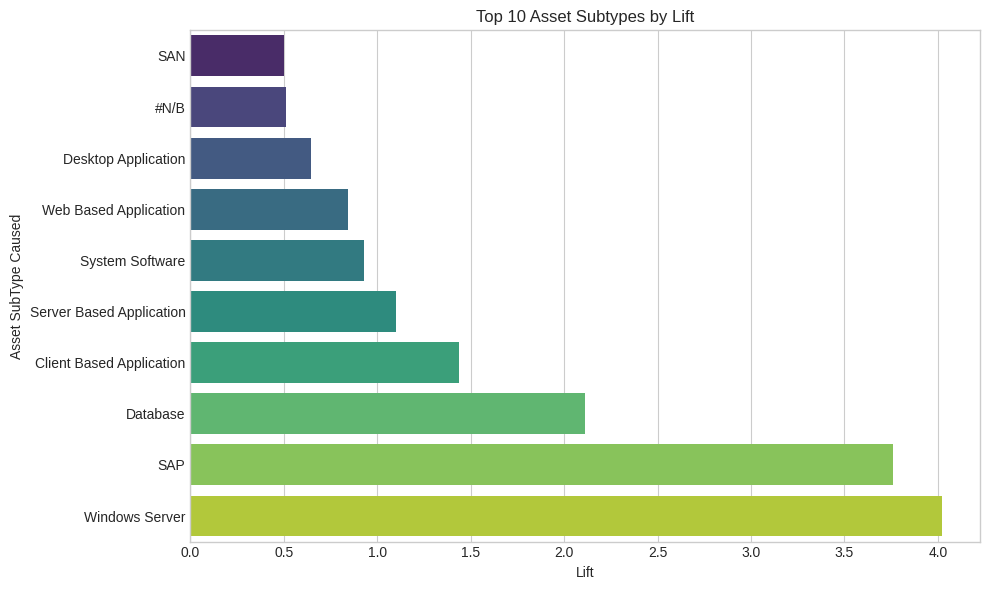

In [31]:
top_subtypes = subtype_comparison.head(10).sort_values('Lift')

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Lift',
    y=top_subtypes.index,
    data=top_subtypes,
    palette='viridis'
)
plt.title("Top 10 Asset Subtypes by Lift")
plt.xlabel("Lift")
plt.ylabel("Asset SubType Caused")
plt.tight_layout()
plt.show()

<ipython-input-32-2d04fdd923aa>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


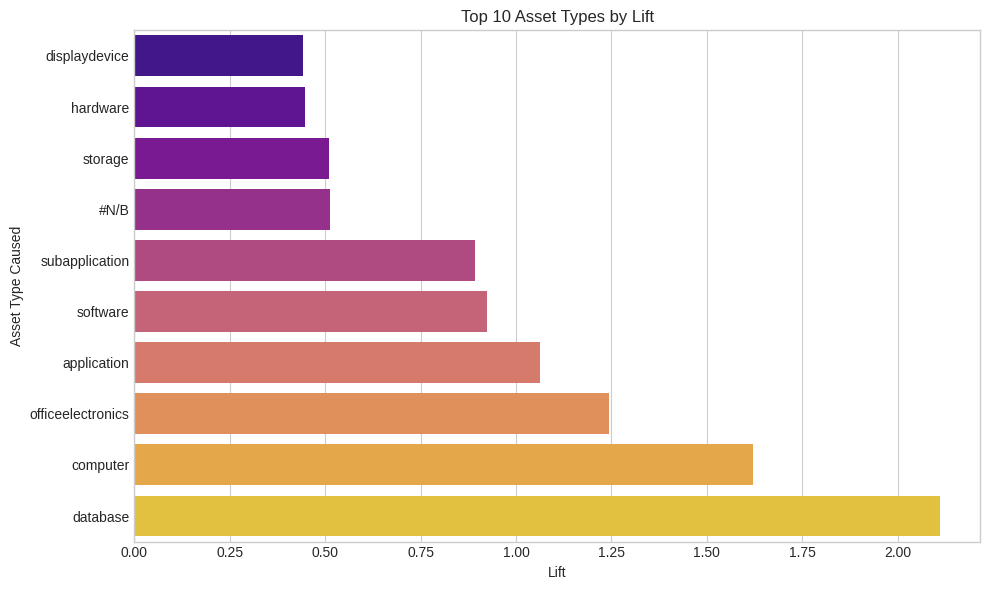

In [32]:
top_types = type_comparison.head(10).sort_values('Lift')

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Lift',
    y=top_types.index,
    data=top_types,
    palette='plasma'
)
plt.title("Top 10 Asset Types by Lift")
plt.xlabel("Lift")
plt.ylabel("Asset Type Caused")
plt.tight_layout()
plt.show()

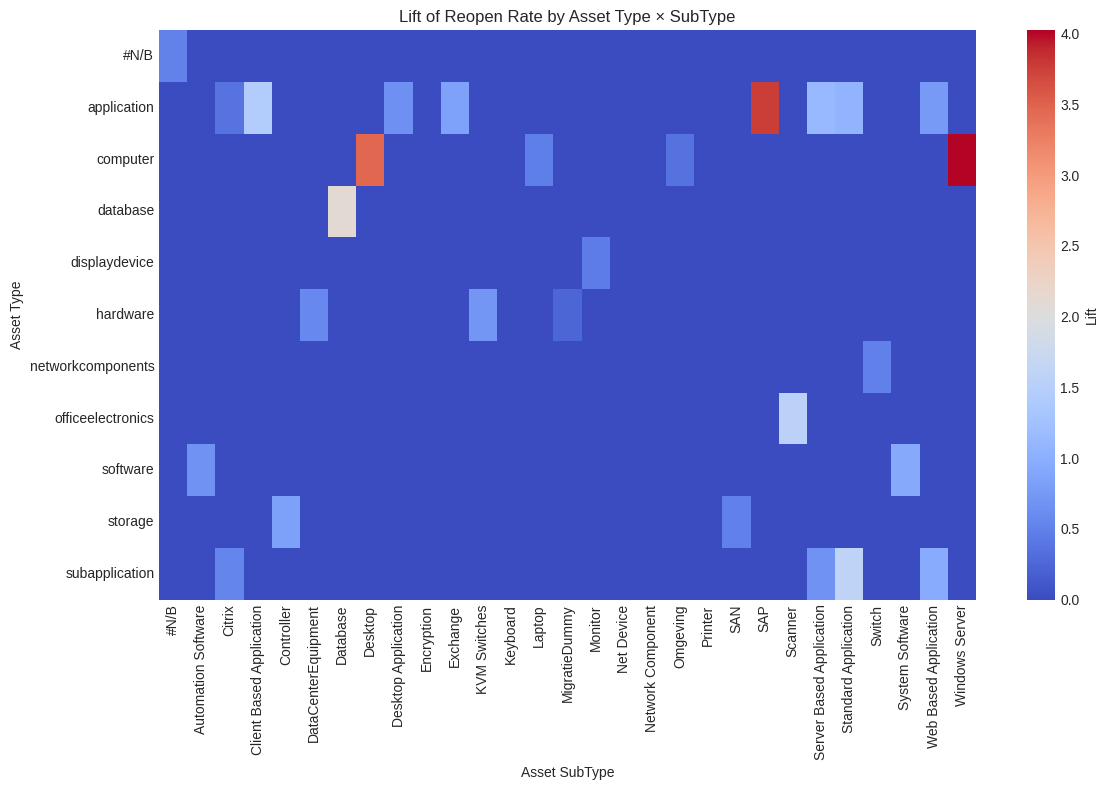

In [33]:
pivot_lift = case_df.groupby(['Asset Type Caused', 'Asset SubType Caused'])['Reopened'].agg(['mean', 'count']).reset_index()
pivot_lift = pivot_lift[pivot_lift['count'] >= 10]
pivot_lift['lift'] = pivot_lift['mean'] / overall_reopen_rate

heatmap_df = pivot_lift.pivot(index='Asset Type Caused', columns='Asset SubType Caused', values='lift').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", cbar_kws={'label': 'Lift'})
plt.title("Lift of Reopen Rate by Asset Type × SubType")
plt.xlabel("Asset SubType")
plt.ylabel("Asset Type")
plt.tight_layout()
plt.show()

## Predicting Reopen Risk: Linear Regression and Classification Tree

To complement the statistical analysis of asset-level reopen rates, we now fit two predictive models to estimate the likelihood of a case being reopened based on its technical attributes. These models serve two purposes:

1. **Linear Regression** – While not ideal for binary classification, it provides an interpretable baseline and allows us to assess which features are linearly associated with higher reopen risk.
2. **Classification Tree** – A non-linear, interpretable model that reveals conditional rules (e.g., "if Asset SubType is X and Closure Code is Y, then risk is high").

We use the following features:
- `Asset Caused` (top frequent assets, one-hot encoded)
- `Asset Type Caused`
- `Asset SubType Caused`
- `Closure Code`

We exclude rare values to reduce noise and improve model generalizability.


In [35]:
# Prepare dataset
model_df = case_df.copy()

# Drop NAs
model_df = model_df.dropna(subset=['Asset Caused', 'Asset Type Caused', 'Asset SubType Caused', 'Closure Code'])

# Select top N categories to encode (avoid too many dummies)
top_assets = model_df['Asset Caused'].value_counts().head(10).index
model_df['Asset Caused'] = model_df['Asset Caused'].apply(lambda x: x if x in top_assets else 'Other')

# Same for types and subtypes
top_types = model_df['Asset Type Caused'].value_counts().head(10).index
model_df['Asset Type Caused'] = model_df['Asset Type Caused'].apply(lambda x: x if x in top_types else 'Other')

top_subtypes = model_df['Asset SubType Caused'].value_counts().head(10).index
model_df['Asset SubType Caused'] = model_df['Asset SubType Caused'].apply(lambda x: x if x in top_subtypes else 'Other')

In [36]:
# Features and target
X = model_df[['Asset Caused', 'Asset Type Caused', 'Asset SubType Caused', 'Closure Code']]
y = model_df['Reopened']

# Preprocessing pipeline
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Linear regression

In [40]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)

print("🔍 Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

🔍 Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      7947
           1       0.09      0.46      0.15       414

    accuracy                           0.74      8361
   macro avg       0.53      0.61      0.50      8361
weighted avg       0.92      0.74      0.81      8361



##Classification Tree

In [41]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

print("🌳 Classification Tree Performance:")
print(classification_report(y_test, y_pred_tree))

🌳 Classification Tree Performance:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      7947
           1       0.13      0.30      0.18       414

    accuracy                           0.86      8361
   macro avg       0.55      0.60      0.55      8361
weighted avg       0.92      0.86      0.89      8361



In [42]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42)

pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', DecisionTreeClassifier(max_depth=4))
])
pipeline_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Asset Caused',
                                                   'Asset Type Caused',
                                                   'Asset SubType Caused',
                                                   'Closure Code'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DecisionTreeClassifier(max_depth=4))])

In [43]:
y_pred_tree = pipeline_smote.predict(X_test)

print("SMOTE + decision tree Performance:")
print(classification_report(y_test, y_pred_tree))

SMOTE + decision tree Performance:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7947
           1       0.13      0.30      0.18       414

    accuracy                           0.87      8361
   macro avg       0.55      0.60      0.56      8361
weighted avg       0.92      0.87      0.89      8361



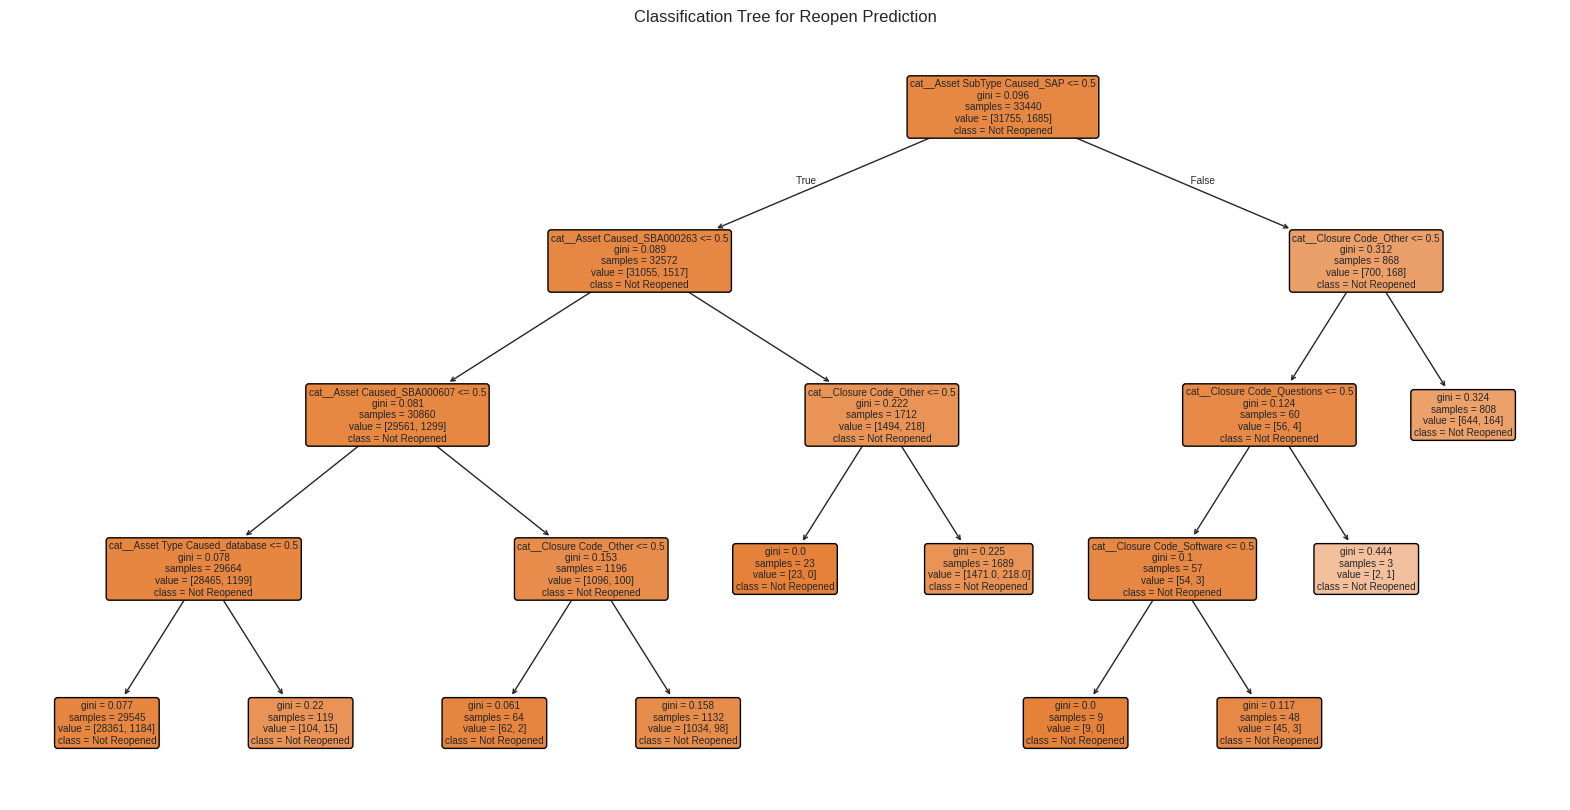

In [39]:
plt.figure(figsize=(20, 10))
feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
plot_tree(tree_pipeline.named_steps['classifier'],
          feature_names=feature_names,
          class_names=['Not Reopened', 'Reopened'],
          filled=True,
          rounded=True)
plt.title("Classification Tree for Reopen Prediction")
plt.show()

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   Incident ID              303819 non-null  object             
 1   Activity                 303819 non-null  object             
 2   ActivityTimeStamp        303819 non-null  datetime64[ns, UTC]
 3   Asset Affected           303819 non-null  object             
 4   Asset Type Affected      303819 non-null  object             
 5   Asset SubType Affected   303819 non-null  object             
 6   Service Affected         303819 non-null  object             
 7   Status                   303819 non-null  object             
 8   Impact                   303819 non-null  int64              
 9   Urgency                  303819 non-null  int64              
 10  Priority                 303819 non-null  int64              
 11  Category     

In [59]:
!pip install imbalanced-learn xgboost --quiet

In [72]:
# ─── 1) INSTALL / IMPORT NECESSARY LIBRARIES ─────────────────────────────────

!pip install pandas numpy scikit-learn imbalanced-learn xgboost tensorflow --quiet

import pandas as pd
import numpy as np

# These will be used downstream:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# We'll also reference SMOTE/ROS later:
from imblearn.over_sampling import SMOTE, RandomOverSampler

# And for LSTM:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


import pandas as pd
import numpy as np

# Scikit‐learn & Imbalanced‐learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE, RandomOverSampler

# TensorFlow Keras (for LSTM)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ─── 2) LOAD & PARSE RAW CSV ─────────────────────────────────────────────────

CSV_PATH = "/content/incidentProcess_custom.csv"  # adjust if needed

data = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",
    thousands=".",
    low_memory=False
)

# 3) PARSE DATES & BASIC FLAGS
# ───────────────────────────────────────────────────────────────────────────────

# Convert to datetime
data["ActivityTimeStamp"] = pd.to_datetime(data["ActivityTimeStamp"], utc=True)
data["Open Time"]  = pd.to_datetime(data["Open Time"],  dayfirst=True)
data["Close Time"] = pd.to_datetime(data["Close Time"], dayfirst=True)
data["Reopen Time"] = pd.to_datetime(data["Reopen Time"], errors="coerce")

# Flag “Reopened” if any non‐null Reopen Time
reopened_ids = data.loc[data["Reopen Time"].notna(), "Incident ID"].unique()
data["Reopened"] = data["Incident ID"].isin(reopened_ids).astype(int)

# Compute handle time in hours (Open → Close)
data["handle_hours"] = (
    (data["Close Time"] - data["Open Time"]).dt.total_seconds() / 3600.0
)

# 4) SORT & COUNT ACTIVITIES
# ───────────────────────────────────────────────────────────────────────────────

data = data.sort_values(["Incident ID", "ActivityTimeStamp"])
activity_counts = (
    data.groupby("Incident ID", sort=False)["Activity"]
    .count()
    .rename("activity_count")
)
data = data.merge(activity_counts, on="Incident ID", how="left")

# 5) “SET ASSET CAUSED → RE‐OPEN” FLAG
# ───────────────────────────────────────────────────────────────────────────────

def setasset_to_reopen_flag(df):
    acts = df["Activity"].tolist()
    for i in range(len(acts) - 1):
        if acts[i] == "Set Asset Caused" and acts[i+1] == "Re-open":
            return 1
    return 0

flag_series = (
    data.groupby("Incident ID", group_keys=False)
        .apply(lambda grp: setasset_to_reopen_flag(grp))
        .rename("setasset_to_reopen")
)
data = data.join(flag_series, on="Incident ID")

def delta_hours_after_setasset(df):
    acts = df["Activity"].tolist()
    times = df["ActivityTimeStamp"].tolist()
    for i in range(len(acts) - 1):
        if acts[i] == "Set Asset Caused" and acts[i+1] == "Re-open":
            return (times[i+1] - times[i]).total_seconds() / 3600.0
    return np.nan

delta_series = (
    data.groupby("Incident ID", group_keys=False)
        .apply(lambda grp: delta_hours_after_setasset(grp))
        .rename("delta_setasset_reopen")
)
data = data.join(delta_series, on="Incident ID")

# 6) BUILD CASE‐LEVEL DATAFRAME
# ───────────────────────────────────────────────────────────────────────────────

case_df = data.groupby("Incident ID", as_index=False).agg({
    "Reopened":                    "max",   # target
    "Asset Caused":                "first",
    "Asset Type Caused":           "first",
    "Asset SubType Caused":        "first",
    "Closure Code":                "first",
    "Priority":                    "first",
    "Impact":                      "first",
    "Urgency":                     "first",
    "Category":                    "first",
    "Assignment Group":            "first",
    "Number of Reassignments":     "first",
    "handle_hours":                "first",
    "activity_count":              "first",
    "setasset_to_reopen":          "first",
    "delta_setasset_reopen":       "first"
})

case_df = case_df.rename(columns={
    "Number of Reassignments": "num_reassignments"
})

# 7) DROP ROWS WITH MISSING IN MANDATORY COLUMNS
# ───────────────────────────────────────────────────────────────────────────────

mandatory_cols = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Priority",
    "Impact",
    "Urgency",
    "Category",
    "Assignment Group",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen",
    "Reopened"
]
before = len(case_df)
case_df = case_df.dropna(subset=mandatory_cols).copy()
after = len(case_df)
print(f"✅ Remaining cases after dropna: {after} (went from {before})")

# (Optional) Convert num_reassignments to integer if desired
case_df["num_reassignments"] = case_df["num_reassignments"].astype(int)


# ───────────────────────────────────────────────────────────────────────────────
# 2) TOP‐10 TRIAGE SIMULATION (Logistic Regression + Precision@10)
# ───────────────────────────────────────────────────────────────────────────────

# 1) SELECT FEATURES & TARGET
FEATURES = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Priority",
    "Impact",
    "Urgency",
    "Category",
    "Assignment Group",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen"
]
TARGET = "Reopened"

X = case_df[FEATURES].copy()
y = case_df[TARGET].copy()

# 2) PREPROCESSING PIPELINE
categorical_cols = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Category",
    "Assignment Group"
]
numeric_cols = [
    "Priority",
    "Impact",
    "Urgency",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen"
]

preprocessor = ColumnTransformer([
    (
      "cat",
      OneHotEncoder(handle_unknown="ignore", sparse_output=False),
      categorical_cols
    ),
    (
      "num",
      StandardScaler(),
      numeric_cols
    )
])

# 3) TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 4) OPTIONAL: APPLY SMOTE or ROS to TRAINING SET ONLY
# Uncomment one of these if you want to balance training data:

#--- SMOTE (synthetic oversampling):
#sm = SMOTE(random_state=42)
#X_train_bal, y_train_bal = sm.fit_resample(
#    pd.DataFrame(preprocessor.fit_transform(X_train)),
#    y_train
#)
# Then you'd skip preprocessor inside the final pipeline. But for simplicity,
# we'll just use class_weight="balanced" in LogisticRegression below.

#--- Random Oversampling:
#ros = RandomOverSampler(random_state=42)
#X_train_bal, y_train_bal = ros.fit_resample(
#    pd.DataFrame(preprocessor.fit_transform(X_train)),
#    y_train
#)

# If you do SMOTE or ROS, you’ll have to restructure your pipeline accordingly.
# For now, we just pass class_weight="balanced" to LogisticRegression.

# 5) BUILD & TRAIN LOGISTIC REGRESSION
pipeline = Pipeline([
    ("preproc", preprocessor),
    (
      "clf",
      LogisticRegression(
          class_weight="balanced",
          max_iter=1000,
          random_state=42
      )
    )
])
pipeline.fit(X_train, y_train)

# 6) EVALUATION ON TEST SET
y_pred = pipeline.predict(X_test)
print("\n🔍 Logistic Regression on TEST set:")
print(classification_report(y_test, y_pred, digits=3))

# 7) TOP‐10 TRIAGE SIMULATION
probs = pipeline.predict_proba(X_test)[:, 1]
test_ids = case_df.loc[X_test.index, "Incident ID"]
df_eval = pd.DataFrame({
    "Incident ID": test_ids.values,
    "TrueLabel":    y_test.values,
    "Score_ReopenProb": probs
})
df_eval_sorted = df_eval.sort_values("Score_ReopenProb", ascending=False).reset_index(drop=True)

print("\n🚀 Top 10 highest‐risk tickets (by predicted probability):")
print(df_eval_sorted.head(10))

n_true_in_top10 = df_eval_sorted.head(10)["TrueLabel"].sum()
precision_at_10 = n_true_in_top10 / 10.0
print(f"\n➡️  Of those top 10, {n_true_in_top10} truly reopened.")
print(f"   Precision@10 = {precision_at_10:.3f}")

<ipython-input-72-0d641eee1f27>:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: setasset_to_reopen_flag(grp))
<ipython-input-72-0d641eee1f27>:110: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: delta_hours_after_setasset(grp))


✅ Remaining cases after dropna: 555 (went from 46601)

🔍 Logistic Regression on TEST set:
              precision    recall  f1-score   support

           0      0.655     0.545     0.595        66
           1      0.464     0.578     0.515        45

    accuracy                          0.559       111
   macro avg      0.559     0.562     0.555       111
weighted avg      0.577     0.559     0.563       111


🚀 Top 10 highest‐risk tickets (by predicted probability):
  Incident ID  TrueLabel  Score_ReopenProb
0   IM0005590          0          0.861857
1   IM0001108          1          0.781348
2   IM0026966          0          0.688883
3   IM0035544          1          0.673476
4   IM0047050          0          0.666825
5   IM0035759          0          0.666336
6   IM0025579          1          0.666127
7   IM0000956          1          0.664696
8   IM0028279          0          0.662651
9   IM0036738          0          0.653696

➡️  Of those top 10, 4 truly reopened.
   Precisio

In [78]:
# ───────────────────────────────────────────────────────────────────────────────
# BLOCK 1: Logistic Regression + Decision Tree (Triage Simulation)
# ───────────────────────────────────────────────────────────────────────────────

# 1) INSTALL + IMPORT DEPENDENCIES
# ───────────────────────────────────────────────────────────────────────────────
#   - pandas, numpy: for DataFrame manipulation
#   - sklearn: for preprocessing, modeling, evaluation
#   - imbalanced‐learn: for SMOTE/oversampling if desired
#   - xgboost: optional, if you want to try a boosted tree
#   - (We only need LogisticRegression & DecisionTreeClassifier here.)
#
!pip install --quiet pandas numpy scikit-learn imbalanced-learn xgboost

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE, RandomOverSampler

# 2) LOAD & PARSE RAW CSV
# ───────────────────────────────────────────────────────────────────────────────
#   - We assume the incident‐level CSV is called "incidentprocess_custom.csv"
#   - It has columns like 'Incident ID', 'Activity', 'Asset Caused', 'Priority', etc.
#   - If your CSV lives elsewhere, update CSV_PATH accordingly.
#
CSV_PATH = "/content/incidentProcess_custom.csv"
data = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",
    thousands=".",
    low_memory=False
)

# 3) PARSE DATETIMES & BUILD “Reopened” FLAG
# ───────────────────────────────────────────────────────────────────────────────
data["ActivityTimeStamp"] = pd.to_datetime(data["ActivityTimeStamp"], utc=True)
data["Open Time"]         = pd.to_datetime(data["Open Time"], dayfirst=True)
data["Close Time"]        = pd.to_datetime(data["Close Time"], dayfirst=True)
data["Reopen Time"]       = pd.to_datetime(data["Reopen Time"], errors="coerce")

# Mark any incident as “reopened” if it ever has a non‐null Reopen Time
reopened_ids = data.loc[data["Reopen Time"].notna(), "Incident ID"].unique()
data["Reopened"] = data["Incident ID"].isin(reopened_ids).astype(int)

# 4) COMPUTE handle_hours & activity_count
# ───────────────────────────────────────────────────────────────────────────────
data["handle_hours"] = (
    (data["Close Time"] - data["Open Time"]).dt.total_seconds() / 3600.0
)
# Count how many activity‐rows per Incident
activity_counts = (
    data.groupby("Incident ID", sort=False)["Activity"]
        .count()
        .rename("activity_count")
)
data = data.merge(activity_counts, on="Incident ID", how="left")

# 5) “Set Asset Caused → Re-open” FEATURES
# ───────────────────────────────────────────────────────────────────────────────
def setasset_to_reopen_flag(grp):
    acts = grp["Activity"].tolist()
    for i in range(len(acts) - 1):
        if acts[i] == "Set Asset Caused" and acts[i+1] == "Re-open":
            return 1
    return 0

flag_series = (
    data.groupby("Incident ID", group_keys=False)
        .apply(setasset_to_reopen_flag)
        .rename("setasset_to_reopen")
)
data = data.join(flag_series, on="Incident ID")

def delta_hours_after_setasset(grp):
    acts = grp["Activity"].tolist()
    times = grp["ActivityTimeStamp"].tolist()
    for i in range(len(acts) - 1):
        if acts[i] == "Set Asset Caused" and acts[i+1] == "Re-open":
            return (times[i+1] - times[i]).total_seconds() / 3600.0
    return np.nan

delta_series = (
    data.groupby("Incident ID", group_keys=False)
        .apply(delta_hours_after_setasset)
        .rename("delta_setasset_reopen")
)
data = data.join(delta_series, on="Incident ID")

# 6) BUILD CASE‐LEVEL DataFrame (one row per Incident)
# ───────────────────────────────────────────────────────────────────────────────
case_df = data.groupby("Incident ID", as_index=False).agg({
    "Reopened":                    "max",    # if any sub-row was reopened → entire incident reopened
    "Asset Caused":                "first",
    "Asset Type Caused":           "first",
    "Asset SubType Caused":        "first",
    "Closure Code":                "first",
    "Priority":                    "first",
    "Impact":                      "first",
    "Urgency":                     "first",
    "Category":                    "first",
    "Assignment Group":            "first",
    "Number of Reassignments":     "first",
    "handle_hours":                "first",
    "activity_count":              "first",
    "setasset_to_reopen":          "first",
    "delta_setasset_reopen":       "first"
})
case_df = case_df.rename(columns={"Number of Reassignments": "num_reassignments"})

# 7) DROP ANY REMAINING NaNs IN FEATURES
# ───────────────────────────────────────────────────────────────────────────────
mandatory_cols = [
    "Asset Caused", "Asset Type Caused", "Asset SubType Caused",
    "Closure Code", "Priority", "Impact", "Urgency", "Category",
    "Assignment Group", "num_reassignments", "handle_hours",
    "activity_count", "setasset_to_reopen", "delta_setasset_reopen",
    "Reopened"
]
before = len(case_df)
case_df = case_df.dropna(subset=mandatory_cols).copy()
after  = len(case_df)
print(f"✅ Remaining cases after dropna: {after} (from {before})")

# Cast reassignments to integer
case_df["num_reassignments"] = case_df["num_reassignments"].astype(int)

# 8) SELECT FEATURES & TARGET
# ───────────────────────────────────────────────────────────────────────────────
FEATURES = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Priority",
    "Impact",
    "Urgency",
    "Category",
    "Assignment Group",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen"
]
TARGET = "Reopened"

X = case_df[FEATURES].copy()
y = case_df[TARGET].copy()

# 9) PREPROCESSING PIPELINE
# ───────────────────────────────────────────────────────────────────────────────
categorical_cols = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Category",
    "Assignment Group"
]
numeric_cols = [
    "Priority",
    "Impact",
    "Urgency",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen"
]

preprocessor = ColumnTransformer([
    (
      "cat",
      OneHotEncoder(handle_unknown="ignore", sparse_output=False),
      categorical_cols
    ),
    (
      "num",
      StandardScaler(),
      numeric_cols
    )
])

# 10) TRAIN/TEST SPLIT (STRATIFY)
# ───────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 11) BUILD + TRAIN LOGISTIC REGRESSION WITH SMOTE
# ───────────────────────────────────────────────────────────────────────────────
pipeline_lr_smote = ImbPipeline([
    ("preproc", preprocessor),
    ("smote",   SMOTE(random_state=42)),
    (
      "clf",
      LogisticRegression(
          class_weight="balanced",
          max_iter=1000,
          random_state=42
      )
    )
])
pipeline_lr_smote.fit(X_train, y_train)

# 12) EVALUATE LOGISTIC REGRESSION (WITH SMOTE) ON TEST SET
# ───────────────────────────────────────────────────────────────────────────────
y_pred_lr = pipeline_lr_smote.predict(X_test)
print("\n🔍 Logistic Regression + SMOTE on TEST set:")
print(classification_report(y_test, y_pred_lr, digits=3))

# 13) BUILD + TRAIN DECISION TREE (depth=20) WITH SMOTE
# ───────────────────────────────────────────────────────────────────────────────
pipeline_tree_smote = ImbPipeline([
    ("preproc", preprocessor),
    ("smote",   SMOTE(random_state=42)),
    (
      "clf",
      DecisionTreeClassifier(
          class_weight="balanced",
          max_depth=20,
          random_state=42
      )
    )
])
pipeline_tree_smote.fit(X_train, y_train)

# 14) EVALUATE DECISION TREE + SMOTE ON TEST SET
# ───────────────────────────────────────────────────────────────────────────────
y_pred_tree = pipeline_tree_smote.predict(X_test)
print("\n🌳 Decision Tree (depth=20) + SMOTE on TEST set:")
print(classification_report(y_test, y_pred_tree, digits=3))

# 15) TOP‐10 TRIAGE SIMULATION FOR LOGISTIC REGRESSION + SMOTE
# ───────────────────────────────────────────────────────────────────────────────
probs_lr = pipeline_lr_smote.predict_proba(X_test)[:, 1]
test_ids = case_df.loc[X_test.index, "Incident ID"]

df_eval_lr = pd.DataFrame({
    "Incident ID":      test_ids.values,
    "TrueLabel":        y_test.values,
    "Score_ReopenProb": probs_lr
})
df_eval_lr = df_eval_lr.sort_values("Score_ReopenProb", ascending=False).reset_index(drop=True)

print("\n🚀 Top 10 highest-risk tickets (LogReg + SMOTE):")
print(df_eval_lr.head(10))

n_true_in_top10 = df_eval_lr.head(10)["TrueLabel"].sum()
precision_at_10 = n_true_in_top10 / 10.0
print(f"\n➡️  Of top 10, {n_true_in_top10} truly reopened → Precision@10 = {precision_at_10:.3f}")

# (Optionally, replicate “Top‐10” for the Decision Tree pipeline)
# probs_tree = pipeline_tree_smote.predict_proba(X_test)[:, 1]
# df_eval_tree = pd.DataFrame({…})
# … same ranking logic …

# ───────────────────────────────────────────────────────────────────────────────

<ipython-input-78-34dd416a0e19>:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(setasset_to_reopen_flag)
<ipython-input-78-34dd416a0e19>:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(delta_hours_after_setasset)


✅ Remaining cases after dropna: 555 (from 46601)

🔍 Logistic Regression + SMOTE on TEST set:
              precision    recall  f1-score   support

           0      0.630     0.515     0.567        66
           1      0.439     0.556     0.490        45

    accuracy                          0.532       111
   macro avg      0.534     0.535     0.528       111
weighted avg      0.552     0.532     0.536       111


🌳 Decision Tree (depth=20) + SMOTE on TEST set:
              precision    recall  f1-score   support

           0      0.677     0.667     0.672        66
           1      0.522     0.533     0.527        45

    accuracy                          0.613       111
   macro avg      0.599     0.600     0.600       111
weighted avg      0.614     0.613     0.613       111


🚀 Top 10 highest-risk tickets (LogReg + SMOTE):
  Incident ID  TrueLabel  Score_ReopenProb
0   IM0005590          0          0.854016
1   IM0001108          1          0.803410
2   IM0026966          0  

In [80]:
# ──────────────────────────────────────────────────────────────────
# ALTERNATIVE 1: RandomOverSampler + Logistic Regression / Tree
# ──────────────────────────────────────────────────────────────────

# 1) INSTALL & IMPORT
!pip install --quiet imbalanced-learn xgboost

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# 2) ASSUME `case_df` ALREADY EXISTS (from Block 1). If not, re‐run Block 1’s aggregation.

# Ensure the same features/columns as Block 1:
FEATURES = [
    "Asset Caused","Asset Type Caused","Asset SubType Caused",
    "Closure Code","Priority","Impact","Urgency","Category",
    "Assignment Group","num_reassignments","handle_hours",
    "activity_count","setasset_to_reopen","delta_setasset_reopen"
]
TARGET = "Reopened"

X = case_df[FEATURES].copy()
y = case_df[TARGET].copy()

# 3) PREPROCESS‐PIPELINE
categorical_cols = [
    "Asset Caused",
    "Asset Type Caused",
    "Asset SubType Caused",
    "Closure Code",
    "Category",
    "Assignment Group"
]
numeric_cols = [
    "Priority",
    "Impact",
    "Urgency",
    "num_reassignments",
    "handle_hours",
    "activity_count",
    "setasset_to_reopen",
    "delta_setasset_reopen"
]

preprocessor = ColumnTransformer([
    (
      "cat",
      OneHotEncoder(handle_unknown="ignore", sparse_output=False),
      categorical_cols
    ),
    (
      "num",
      StandardScaler(),
      numeric_cols
    )
])

# 4) TRAIN/TEST SPLIT (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 5) PIPELINE A: Logistic Regression + RandomOverSampler
pipeline_lr_ros = ImbPipeline([
    ("preproc", preprocessor),
    ("ros",     RandomOverSampler(random_state=42)),
    (
      "clf",
      LogisticRegression(
          class_weight="balanced",
          max_iter=1000,
          random_state=42
      )
    )
])
pipeline_lr_ros.fit(X_train, y_train)

print("\n🔍 Logistic Regression + RandomOverSampler:")
y_pred_lr_ros = pipeline_lr_ros.predict(X_test)
print(classification_report(y_test, y_pred_lr_ros, digits=3))

# 6) PIPELINE B: Decision Tree (depth=20) + RandomOverSampler
pipeline_tree_ros = ImbPipeline([
    ("preproc", preprocessor),
    ("ros",     RandomOverSampler(random_state=42)),
    (
      "clf",
      DecisionTreeClassifier(
          class_weight="balanced",
          max_depth=20,
          random_state=42
      )
    )
])
pipeline_tree_ros.fit(X_train, y_train)

print("\n🌳 Decision Tree (depth=20) + RandomOverSampler:")
y_pred_tree_ros = pipeline_tree_ros.predict(X_test)
print(classification_report(y_test, y_pred_tree_ros, digits=3))

# 7) OPTIONAL: Try a RandomForest with class_weight (no oversampling)
rf = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=200,
    max_depth=15,
    random_state=42
)
pipeline_rf = ImbPipeline([
    ("preproc", preprocessor),
    ("clf",     rf)
])
pipeline_rf.fit(X_train, y_train)

print("\n🌲 RandomForest (class_weight=balanced) without oversampling:")
y_pred_rf = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, digits=3))



🔍 Logistic Regression + RandomOverSampler:
              precision    recall  f1-score   support

           0      0.648     0.530     0.583        66
           1      0.456     0.578     0.510        45

    accuracy                          0.550       111
   macro avg      0.552     0.554     0.547       111
weighted avg      0.570     0.550     0.554       111


🌳 Decision Tree (depth=20) + RandomOverSampler:
              precision    recall  f1-score   support

           0      0.561     0.561     0.561        66
           1      0.356     0.356     0.356        45

    accuracy                          0.477       111
   macro avg      0.458     0.458     0.458       111
weighted avg      0.477     0.477     0.477       111


🌲 RandomForest (class_weight=balanced) without oversampling:
              precision    recall  f1-score   support

           0      0.691     0.712     0.701        66
           1      0.558     0.533     0.545        45

    accuracy               

In [81]:
# ───────────────────────────────────────
# ALTERNATIVE 2: SMOTEENN  + Decision Tree
#            OR    ADASYN + Logistic
# ───────────────────────────────────────

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import ADASYN

# (Reuse `preprocessor`, X_train, X_test, etc. from above)

# 1) PIPELINE A: Decision Tree + SMOTEENN
pipeline_tree_smoteenn = ImbPipeline([
    ("preproc", preprocessor),
    ("smoteenn", SMOTEENN(random_state=42)),
    (
      "clf",
      DecisionTreeClassifier(
          class_weight="balanced",
          max_depth=20,
          random_state=42
      )
    )
])
pipeline_tree_smoteenn.fit(X_train, y_train)

print("\n🌳 Decision Tree + SMOTEENN:")
y_pred_te = pipeline_tree_smoteenn.predict(X_test)
print(classification_report(y_test, y_pred_te, digits=3))

# 2) PIPELINE B: Logistic Regression + ADASYN
pipeline_lr_adasyn = ImbPipeline([
    ("preproc",  preprocessor),
    ("adasyn",   ADASYN(random_state=42, n_neighbors=5)),
    (
      "clf",
      LogisticRegression(
          class_weight="balanced",
          max_iter=1000,
          random_state=42
      )
    )
])
pipeline_lr_adasyn.fit(X_train, y_train)

print("\n🔍 Logistic Regression + ADASYN:")
y_pred_la = pipeline_lr_adasyn.predict(X_test)
print(classification_report(y_test, y_pred_la, digits=3))

# 3) PIPELINE C: XGBoost with scale_pos_weight
import xgboost as xgb

# Compute scale_pos_weight = (#negatives / #positives) in TRAIN
num_neg = sum(y_train == 0)
num_pos = sum(y_train == 1)
scale_pos_w = num_neg / max(1, num_pos)

model_xgb = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    scale_pos_weight=scale_pos_w,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

pipeline_xgb = ImbPipeline([
    ("preproc", preprocessor),
    ("xgb",     model_xgb)
])
pipeline_xgb.fit(X_train, y_train)

print("\n🚀 XGBoost (scale_pos_weight) without explicit oversampling:")
y_pred_xgb = pipeline_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, digits=3))


🌳 Decision Tree + SMOTEENN:
              precision    recall  f1-score   support

           0      0.710     0.333     0.454        66
           1      0.450     0.800     0.576        45

    accuracy                          0.523       111
   macro avg      0.580     0.567     0.515       111
weighted avg      0.604     0.523     0.503       111


🔍 Logistic Regression + ADASYN:
              precision    recall  f1-score   support

           0      0.648     0.530     0.583        66
           1      0.456     0.578     0.510        45

    accuracy                          0.550       111
   macro avg      0.552     0.554     0.547       111
weighted avg      0.570     0.550     0.554       111



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:32:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🚀 XGBoost (scale_pos_weight) without explicit oversampling:
              precision    recall  f1-score   support

           0      0.610     0.545     0.576        66
           1      0.423     0.489     0.454        45

    accuracy                          0.523       111
   macro avg      0.517     0.517     0.515       111
weighted avg      0.534     0.523     0.526       111



In [82]:
# ─────────────────────────────────────────────────────────────────
# ALTERNATIVE 3: Hyperparameter‐Tuned XGBoost (no oversampling)
# ─────────────────────────────────────────────────────────────────

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# (Reuse `preprocessor`, X_train, X_test, y_train, y_test` from above)

# 1) Compute scale_pos_weight
num_neg = sum(y_train == 0)
num_pos = sum(y_train == 1)
scale_pos_w = num_neg / max(1, num_pos)

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="auc",
    scale_pos_weight=scale_pos_w,
    random_state=42
)

pipeline_xgb_tune = ImbPipeline([
    ("preproc", preprocessor),
    ("xgb",     xgb_model)
])

param_grid = {
    "xgb__n_estimators":    [100, 200],
    "xgb__max_depth":       [4, 6, 8],
    "xgb__learning_rate":   [0.01, 0.1],
    "xgb__subsample":       [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    pipeline_xgb_tune,
    param_grid,
    scoring="f1",          # maximize F1 or precision/recall trade‐off
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("\n🏆 Best XGBoost params:", grid.best_params_)
best_xgb = grid.best_estimator_

print("\n✨ XGBoost (tuned) on TEST set:")
y_pred_best = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_best, digits=3))

Fitting 3 folds for each of 48 candidates, totalling 144 fits

🏆 Best XGBoost params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 4, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}

✨ XGBoost (tuned) on TEST set:
              precision    recall  f1-score   support

           0      0.661     0.561     0.607        66
           1      0.473     0.578     0.520        45

    accuracy                          0.568       111
   macro avg      0.567     0.569     0.563       111
weighted avg      0.585     0.568     0.571       111



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:33:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2: Activity‐Sequence LSTM Pipeline (from raw event‐log → Reopen prediction)
# ─────────────────────────────────────────────────────────────────────────────

# 1) INSTALL & IMPORT
!pip install --quiet tensorflow keras

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



# 2) ASSUME “data” (the **raw event‐log**) IS IN MEMORY
#
# This DataFrame must be the original 300k+ row log, containing columns:
#    - Incident ID          (string, e.g. 'IM0000142')
#    - Activity             (string, e.g. 'Open', 'Assign to 1st Line Operator', etc.)
#    - ActivityTimeStamp    (datetime)
#    - Reopen Time          (nullable datetime)
#    - … plus all other columns. For LSTM we only need Incident ID, Activity, ActivityTimeStamp, and the case‐level “Reopened” that we computed.
#
# If your DataFrame is named `data`, ensure:
#    data["ActivityTimeStamp"] is of dtype datetime64
#    data["Reopen Time"] may be null or not null
#
# Let’s double‐check:
print("Raw event‐log sample:")
display(data.head())
print("\nColumns:", data.columns)
print("\nDtypes:\n", data.dtypes)


# 3) ENSURE “Reopened” FLAG EXISTS AT ROW LEVEL (0/1) FOR EVERY EVENT
#
#    We need a column “Reopened” that is 1 if that ticket ever had a Reopen, else 0.
#
if "Reopened" not in data.columns:
    reopened_ids = data.loc[data["Reopen Time"].notna(), "Incident ID"].unique()
    data["Reopened"] = data["Incident ID"].isin(reopened_ids).astype(int)

# Confirm:
print("\nUnique Reopened values:", data["Reopened"].unique())
print("Total events:", len(data))
print("Total reopened events:", data["Reopened"].sum())


# 4) EXTRACT ACTIVITY SEQUENCES AT CASE LEVEL
#
# a) Sort the entire DataFrame by Incident ID then by ActivityTimeStamp
# b) Group by Incident ID, collecting the “Activity” column into a Python list for each case
#
# NOTE: The KeyError earlier (“ActivityTimeStamp” missing) happens if your column was renamed.
#       Make sure it is spelled exactly “ActivityTimeStamp” (case‐sensitive) and dtype datetime.
#
data = data.sort_values(["Incident ID", "ActivityTimeStamp"], ascending=[True, True])

# Now group: each “act_sequence” is the ordered list of activities for that case
seqs_grouped = data.groupby("Incident ID", sort=False)["Activity"].apply(list).rename("act_sequence")

# Build our “seq_df” which has one row per Incident:
seq_df = pd.DataFrame({
    "Incident ID": seqs_grouped.index,
    "act_sequence": seqs_grouped.values,
    "Reopened": data.groupby("Incident ID")["Reopened"].first().values
})

print(f"\n➡️ {len(seq_df)} cases with sequences.")
print("Sample:")
display(seq_df.head(3))


# 5) TOKENIZE THE ACTIVITY VOCABULARY
#
#    - We treat each activity‐string as a “token” (e.g. “Open”, “Assign to 1st Line Operator”, etc.).
#    - Let the Keras Tokenizer learn a mapping from activity → integer (1..vocab_size).
#
all_sequences = seq_df["act_sequence"].tolist()
# Keras Tokenizer expects either a list of strings or a list of “space-separated tokens”,
# but here we already have a list of tokens per case. We can re‐join with a space:
joined = [" ".join(seq) for seq in all_sequences]

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(joined)  # learns word_index mapping

# Vocabulary size (include 1 extra for OOV, and 0 is reserved for padding)
vocab_size = len(tokenizer.word_index) + 1
print(f"\nVocabulary size (including OOV and pad=0): {vocab_size}")


# 6) CONVERT EACH CASE’S ACTIVITY LIST → INTEGER SEQUENCE & PAD TO MAX_LEN
#
#    - texts_to_sequences() will convert “Open Assign Close…” → [3, 17, 22, …]
#    - pad_sequences() will pad (pre‐ or post‐) so that all sequences have the same length.
#
sequences = tokenizer.texts_to_sequences(joined)

# Decide a suitable maxlen. We can take the 95th percentile of sequence lengths or simply max.
lengths = [len(s) for s in sequences]
max_len = int(np.percentile(lengths, 95))  # use 95th percentile to avoid extremely long sequences
print(f"Sequence length 95th percentile: {max_len}")
print("Longest sequence length:", max(lengths))

# Pad (post‐truncate if longer than max_len, post‐pad if shorter)
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("\n➡️ Padded sequences shape:", padded_sequences.shape)
# Each row is length=max_len, each column is an integer token ∈ [1..vocab_size-1], 0=PAD


# 7) SPLIT INTO TRAIN & TEST for the LSTM
X_seq = padded_sequences
y_seq = seq_df["Reopened"].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.20,
    stratify=y_seq,
    random_state=42
)

print(f"\nTraining cases: {len(X_train_seq)}, Testing cases: {len(X_test_seq)}")
print("Reopened ratio in TRAIN:", np.mean(y_train_seq),
      "Reopened ratio in TEST:", np.mean(y_test_seq))


# 8) BUILD THE LSTM MODEL
#
#    Architecture:
#      1. Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len)
#      2. LSTM(units=64, return_sequences=False)  # you can stack more LSTMs if you like
#      3. Dense(32, activation='relu')
#      4. Dropout(0.3)
#      5. Dense(1, activation='sigmoid')
#
embed_dim = 32

model = Sequential()
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_len
    )
)  # [batch_size, max_len] → [batch_size, max_len, embed_dim]

model.add(
    LSTM(
        units=64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)  # [batch_size, max_len, embed_dim] → [batch_size, 64]

model.add(
    Dense(
        units=32,
        activation="relu"
    )
)  # [batch_size, 64] → [batch_size, 32]
model.add(Dropout(0.3))
model.add(Dense(units=1, activation="sigmoid"))  # [batch_size, 32] → [batch_size, 1]

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("\n📋 LSTM Model Summary:")
model.summary()


# 9) TRAIN THE LSTM
#
#    Because the data is imbalanced, we can pass class_weight or use oversampling at the sequence level.
#    For simplicity, we’ll pass class_weight to give extra weight to the reopened (1) class.
#
# Compute class weights: {0:1.0, 1: (num_neg/num_pos)}
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_seq)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)
class_weight_dict = dict(zip(classes, class_weights))
print("\nClass weights passed to LSTM:", class_weight_dict)

# Use EarlyStopping to avoid overfitting
es = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.10,
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=1
)


# 10) EVALUATE LSTM ON TEST SET
y_pred_seq_prob = model.predict(X_test_seq).ravel()
y_pred_seq = (y_pred_seq_prob >= 0.5).astype(int)

print("\n🔍 LSTM classification report on TEST set:")
print(classification_report(y_test_seq, y_pred_seq, digits=3))


# 11) PRECISION@K (Top‐10 Triage Simulation)
#
#    We take the test set, sort by predicted probability descending,
#    and see how many of the top 10 truly reopened.
#
df_test = pd.DataFrame({
    "Incident ID": seq_df.iloc[y_test_seq.index]["Incident ID"],
    "TrueLabel": y_test_seq,
    "PredScore": y_pred_seq_prob
})
df_test_sorted = df_test.sort_values("PredScore", ascending=False)

top_k = df_test_sorted.head(10)
num_true_in_topk = top_k["TrueLabel"].sum()
precision_at_10 = num_true_in_topk / 10.0

print("\n🚀 Top 10 highest‐risk tickets by LSTM probability:")
display(top_k.reset_index(drop=True))
print(f"➡️ Of those top 10, {int(num_true_in_topk)} truly reopened → Precision@10 = {precision_at_10:.3f}")


Raw event‐log sample:


,Incident ID,Activity,ActivityTimeStamp,Asset Affected,Asset Type Affected,Asset SubType Affected,Service Affected,Status,Impact,Urgency,...,Resolved Time,Close Time,Handle Time (Hours),Closure Code,Asset Caused,Asset Type Caused,Asset SubType Caused,Service Caused,Assignment Group,Reopened
0,IM0000004,Assign to 2nd Line Operator,2013-01-07 08:17:17+00:00,SUB000508,subapplication,Web Based Application,SRVC000162,Closed,4,4,...,04/11/2013 13:50:27,04/11/2013 13:51:17,3871.691111,Other,SUB000508,subapplication,Web Based Application,SRVC000162,TEAM0001,0
1,IM0000004,Assign to 1st Line Operator,2013-11-04 12:09:37+00:00,SUB000508,subapplication,Web Based Application,SRVC000162,Closed,4,4,...,04/11/2013 13:50:27,04/11/2013 13:51:17,3871.691111,Other,SUB000508,subapplication,Web Based Application,SRVC000162,TEAM0003,0
2,IM0000004,Assign to 2nd Line Operator,2013-11-04 12:09:38+00:00,SUB000508,subapplication,Web Based Application,SRVC000162,Closed,4,4,...,04/11/2013 13:50:27,04/11/2013 13:51:17,3871.691111,Other,SUB000508,subapplication,Web Based Application,SRVC000162,TEAM0003,0
3,IM0000004,Assign to 1st Line Operator,2013-11-04 13:41:30+00:00,SUB000508,subapplication,Web Based Application,SRVC000162,Closed,4,4,...,04/11/2013 13:50:27,04/11/2013 13:51:17,3871.691111,Other,SUB000508,subapplication,Web Based Application,SRVC000162,TEAM0002,0
4,IM0000004,Assign to 2nd Line Operator,2013-11-04 13:41:31+00:00,SUB000508,subapplication,Web Based Application,SRVC000162,Closed,4,4,...,04/11/2013 13:50:27,04/11/2013 13:51:17,3871.691111,Other,SUB000508,subapplication,Web Based Application,SRVC000162,TEAM0002,0



Columns: Index(['Incident ID', 'Activity', 'ActivityTimeStamp', 'Asset Affected',
       'Asset Type Affected', 'Asset SubType Affected', 'Service Affected',
       'Status', 'Impact', 'Urgency', 'Priority', 'Category',
       'Number of Reassignments', 'Open Time', 'Reopen Time', 'Resolved Time',
       'Close Time', 'Handle Time (Hours)', 'Closure Code', 'Asset Caused',
       'Asset Type Caused', 'Asset SubType Caused', 'Service Caused',
       'Assignment Group', 'Reopened'],
      dtype='object')

Dtypes:
 Incident ID                             object
Activity                                object
ActivityTimeStamp          datetime64[ns, UTC]
Asset Affected                          object
Asset Type Affected                     object
Asset SubType Affected                  object
Service Affected                        object
Status                                  object
Impact                                   int64
Urgency                                  int64
Priority    

,Incident ID,act_sequence,Reopened
0,IM0000004,"[Assign to 2nd Line Operator, Assign to 1st Li...",0
1,IM0000005,"[Assign to 2nd Line Operator, Update Descripti...",1
2,IM0000006,"[Close, Set Asset Caused]",0



Vocabulary size (including OOV and pad=0): 31
Sequence length 95th percentile: 65
Longest sequence length: 570

➡️ Padded sequences shape: (46601, 65)

Training cases: 37280, Testing cases: 9321
Reopened ratio in TRAIN: 0.01869635193133047 Reopened ratio in TEST: 0.018667524943675573

📋 LSTM Model Summary:


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Class weights passed to LSTM: {np.int64(0): np.float64(0.5095262826996145), np.int64(1): np.float64(26.74318507890961)}
Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 55s 95ms/step - accuracy: 0.6725 - loss: 0.6459 - val_accuracy: 0.7731 - val_loss: 0.4464
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.7236 - loss: 0.5293 - val_accuracy: 0.9295 - val_loss: 0.1885
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 49s 93ms/step - accuracy: 0.8398 - loss: 0.3486 - val_accuracy: 0.9319 - val_loss: 0.1876
Epoch 4/10
237/525 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.9245 - loss: 0.2428

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK: Revised LSTM Pipeline (with nonzero parameters)
# ─────────────────────────────────────────────────────────────────────────────

# 1) Install & Imports (run once)
!pip install --quiet tensorflow keras

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



# 2) ASSUME RAW EVENT‐LOG “data” EXISTS IN YOUR ENVIRONMENT
#    - Must have columns: "Incident ID", "Activity", "ActivityTimeStamp", and a 0/1 "Reopened" column at row level.
#    - We sort and group to build “seq_df” with one row per ticket.

# Example check (remove these two lines if your "data" already loaded):
# data = pd.read_csv("/content/incidentprocess_custom.csv", sep=";", parse_dates=["ActivityTimeStamp", "Open Time", "Close Time"])
# … then compute data["Reopened"] if missing.

# 2.1) Ensure “ActivityTimeStamp” is datetime
if not np.issubdtype(data["ActivityTimeStamp"].dtype, np.datetime64):
    data["ActivityTimeStamp"] = pd.to_datetime(data["ActivityTimeStamp"], dayfirst=True)

# 2.2) If “Reopened” flag missing, create it by checking “Reopen Time”
if "Reopened" not in data.columns:
    reopened_ids = data.loc[data["Reopen Time"].notna(), "Incident ID"].unique()
    data["Reopened"] = data["Incident ID"].isin(reopened_ids).astype(int)

# 2.3) Sort by Incident ID, then by timestamp
data = data.sort_values(by=["Incident ID", "ActivityTimeStamp"], ascending=[True, True])

# 2.4) Group by Incident ID → build “act_sequence” and pull the first Reopened flag per ID
seqs_grouped = data.groupby("Incident ID", sort=False)["Activity"].apply(list).rename("act_sequence")
reopen_flags = data.groupby("Incident ID", sort=False)["Reopened"].first().rename("Reopened")

seq_df = pd.DataFrame({
    "Incident ID": seqs_grouped.index,
    "act_sequence": seqs_grouped.values,
    "Reopened": reopen_flags.values
})

print(f"Total tickets (cases): {len(seq_df)}")
print("seq_df sample:")
display(seq_df.head(3))



# 3) TOKENIZE THE ACTIVITY SEQUENCES
#    - We join each list-of-Activity into a single space‐delimited string for the Keras Tokenizer.
all_texts = [" ".join(seq) for seq in seq_df["act_sequence"].tolist()]

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(all_texts)

# Vocabulary size: +1 since Keras reserves index=0 for padding
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")

# 4) TURN EACH SEQUENCE INTO INTEGER SEQ & PAD
sequences = tokenizer.texts_to_sequences(all_texts)
lengths = [len(s) for s in sequences]
max_len = int(np.percentile(lengths, 95))  # 95th percentile length
max_len = max(1, max_len)  # ensure at least 1

print(f"95th percentile for sequence length: {max_len}")
print(f"Longest length in data: {max(lengths)}")

padded = pad_sequences(
    sequences,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Padded shape:", padded.shape)  # Expect (num_cases, max_len)


# 5) SPLIT INTO TRAIN/TEST
X_seq = padded
y_seq = seq_df["Reopened"].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.20,
    stratify=y_seq,
    random_state=42
)

print(f"Train size: {len(X_train_seq)}, Test size: {len(X_test_seq)}")
print("Reopened ratio in train:", np.mean(y_train_seq),
      "Reopened ratio in test:", np.mean(y_test_seq))



# 6) BUILD & COMPILE LSTM MODEL
#
#    Carefully specify input_dim (vocab_size), output_dim (embedding dimension), and input_length (max_len).
#
embed_dim = 64  # You can adjust 32, 64, etc.

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_len,
        name="embedding_layer"
    ),
    LSTM(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2,
        name="lstm_layer"
    ),
    Dense(
        units=32,
        activation="relu",
        name="dense_relu"
    ),
    Dropout(0.3, name="dropout_layer"),
    Dense(
        units=1,
        activation="sigmoid",
        name="output_layer"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\n🔧 LSTM Model Summary (should show nonzero params):")
model.summary()


# 7) COMPUTE CLASS WEIGHTS TO OFFSET IMBALANCE
classes = np.unique(y_train_seq)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
class_weight_dict = dict(zip(classes, weights))
print("\nClass weights:", class_weight_dict)


# 8) TRAIN WITH EARLY STOPPING
es = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=1
)


# 9) EVALUATE ON TEST SET
y_pred_prob = model.predict(X_test_seq).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\n🔍 LSTM classification report on TEST set:")
print(classification_report(y_test_seq, y_pred, digits=4))


# 10) PRECISION@10 FOR TOP‐K TRIAGE SIMULATION
df_eval = pd.DataFrame({
    "Incident ID": seq_df.iloc[y_test_seq.index]["Incident ID"],
    "TrueLabel": y_test_seq,
    "Score": y_pred_prob
})
df_sorted = df_eval.sort_values("Score", ascending=False).reset_index(drop=True)

top10 = df_sorted.head(10)
num_true = top10["TrueLabel"].sum()
precision_at_10 = num_true / 10.0

print("\n🚀 Top 10 highest‐risk tickets by LSTM score:")
display(top10)
print(f"➡️ Precision@10 = {precision_at_10:.3f} ({int(num_true)}/10 truly reopened)")